# Boosting
This script grogramms Boosting.

#### Libraries

In [1]:
!pip install -q xgboost shap
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import shap

In [2]:
SEED = 123
plt.style.use('seaborn-v0_8-whitegrid')

Connect to Google drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import_path = '/content/drive/MyDrive/IMT_studies/ML_econ/Project/Data/Cleaned/'
export_path = '/content/drive/MyDrive/IMT_studies/ML_econ/Project/Data/Cleaned/'

Data uploading

In [5]:
merged_main = pd.read_csv(import_path + "merged_main_final.csv",
                          dtype={"exp_iso3": str, "imp_iso3": str})
merged_robust = pd.read_csv(import_path + "merged_robust_final.csv",
                            dtype={"exp_iso3": str, "imp_iso3": str})
print(merged_main.shape, merged_robust.shape)

/tmp/ipykernel_668/1870831702.py:3: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_robust = pd.read_csv(import_path + "merged_robust_final.csv",


(1404170, 54) (1404170, 54)


In [6]:
# ── Feature set: sanctions + gravity controls (no FE in trees) ──
sanc_feats = [
    "sanc_arms","sanc_military","sanc_trade","sanc_financial","sanc_travel","sanc_other",
    "target_mult","sender_mult",
    "descr_exp_compl","descr_exp_part","descr_imp_compl","descr_imp_part",
    "obj_democracy","obj_destab_regime","obj_end_war","obj_human_rights","obj_other",
    "obj_policy_change","obj_prevent_war","obj_territorial_conflict","obj_terrorism",
]

# show every non-sanction column so you can identify the gravity controls
print([c for c in merged_main.columns if c not in sanc_feats])

['year', 'exp_iso3', 'imp_iso3', 'exp_id', 'imp_id', 'trade', 'trade_comtrade', 'dist', 'dist_cap', 'dist_w_harm', 'dist_w_arith', 'dist_w_harm_jh', 'dist_w_arith_jh', 'contig', 'comlang', 'comcol', 'colony', 'exp_gdp', 'imp_gdp', 'exp_gdppc', 'imp_gdppc', 'exp_pop', 'imp_pop', 'fta', 'exp_eu', 'imp_eu', 'exp_wto', 'imp_wto', 'case_id', 'sanctioned_any', 'rta_Goods', 'rta_Goods & Services', 'rta_Services']


In [7]:
grav_feats = [
    "dist_w_harm",                      # distance (population-weighted harmonic)
    "contig", "comlang", "comcol", "colony",   # geography / historical ties
    "exp_gdp", "imp_gdp",               # economic size (levels)
    "exp_pop", "imp_pop",               # population
    "fta",                              # free-trade agreement
    "exp_eu", "imp_eu", "exp_wto", "imp_wto",  # bloc / institution membership
]

feature_cols = sanc_feats + grav_feats
missing = [c for c in feature_cols if c not in merged_main.columns]
assert not missing, f"not in panel: {missing}"
print(len(feature_cols), "total features")

35 total features


#### Train and test sampling

In [8]:
X = merged_main[feature_cols].values
y = np.log1p(merged_main["trade"].values)   # log(1+trade): keeps zeros, comparable to PPML

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED)
print(X_train.shape, X_test.shape)

(982919, 35) (421251, 35)


## XGBoost

**XGBoost (Extreme Gradient Boosting)** is an ensemble method that builds decision trees sequentially, with each new tree correcting errors made by the previous trees.

The prediction for observation $i$ is the sum of the predictions from all trees:

$$\hat{y}*i = \sum*{m=1}^{M} f_m(x_i)$$

where $f_m(x_i)$ is the prediction of tree $m$ and $M$ is the total number of trees.

XGBoost minimizes a regularized objective:

$$L = \sum_{i=1}^{n} l(y_i,\hat{y}*i) + \sum*{m=1}^{M}\Omega(f_m)$$

where $l(y_i,\hat{y}_i)$ measures prediction error and $\Omega(f_m)$ penalizes overly complex trees.

Thus, XGBoost captures **non-linear relationships and interactions between variables** while regularization helps prevent overfitting. Unlike Lasso, it does not estimate a single coefficient for each variable; effects are determined through the structure and splits of the ensemble of trees.


In [9]:
xgb_model = xgb.XGBRegressor(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, n_jobs=-1, tree_method="hist"   # hist = fast on 1M+ rows
)
xgb_model.fit(X_train, y_train)

from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
pred = xgb_model.predict(X_test)
print(f"Test R²  : {r2_score(y_test, pred):.4f}")
print(f"Test RMSE: {root_mean_squared_error(y_test, pred):.4f}")

Test R²  : 0.7994
Test RMSE: 2.0698


### SHAP

XGBoost does not produce one coefficient per variable, so interpretation usually relies on **feature importance** and **SHAP values**.

**Feature importance** measures how useful a variable is for improving predictions across the trees. A variable with higher importance contributes more to the model, but importance alone does not show whether the effect is positive or negative.

**SHAP values** provide observation-level interpretations. For observation $i$, the prediction can be decomposed as:

$$\hat{y}*i = \phi_0 + \phi*{i1} + \phi_{i2} + \cdots + \phi_{ip}$$

where $\phi_0$ is the baseline prediction and $\phi_{ik}$ is the SHAP contribution of variable $k$ for observation $i$.

A positive SHAP value means that the variable pushes the prediction **up**, while a negative SHAP value pushes the prediction **down**.

Therefore, SHAP values help interpret both the **importance** and the **direction of influence** of each variable in the XGBoost model.

### Additional Note: Math Behind XGBoost Interpretation

For XGBoost, the prediction is an additive combination of trees:

$$\hat{y}_i = f_1(x_i) + f_2(x_i) + \cdots + f_M(x_i)$$

where $f_1(x_i), f_2(x_i), \ldots, f_M(x_i)$ are the predictions contributed by trees $1,2,\ldots,M$ for observation $i$.

Since there is no single coefficient $\beta_k$ for each variable, variable effects are interpreted using **feature importance** and **SHAP values**.

For feature importance based on **gain**, XGBoost measures how much the loss function improves when a variable is used for a tree split. Larger gain means that the variable contributes more to improving model predictions.

SHAP values are based on **Shapley values** from cooperative game theory. The contribution of variable $k$ is:

$$
\phi_k =
\sum_{S \subseteq F \setminus {k}}
\frac{|S|!(p-|S|-1)!}{p!}
\left[
f(S \cup {k}) - f(S)
\right]
$$

where $S$ is a subset of the other variables and $f(S \cup {k}) - f(S)$ measures how much adding variable $k$ changes the prediction.

The weights average this marginal contribution over all possible combinations of variables. Therefore, SHAP measures the **average contribution of each variable to the prediction**, accounting for interactions with the other variables.

For each observation:

$$\hat{y}*i = \phi_0 + \phi_{i1} + \phi_{i2} + \cdots + \phi_{ip}$$

where $\phi_0$ is the baseline prediction and $\phi_{ik}$ is the contribution of variable $k$ to observation $i$.

Thus:

* $\phi_{ik} > 0$: variable $k$ pushes the prediction upward
* $\phi_{ik} < 0$: variable $k$ pushes the prediction downward
* large $|\phi_{ik}|$: variable $k$ has a strong influence on that prediction


In [10]:
# subsample test set — exact TreeSHAP on 421K rows is slow and unreadable
shap_idx = np.random.RandomState(SEED).choice(len(X_test), 5000, replace=False)
X_shap = X_test[shap_idx]

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)
print("SHAP values shape:", shap_values.shape)   # (5000, 35)

SHAP values shape: (5000, 35)


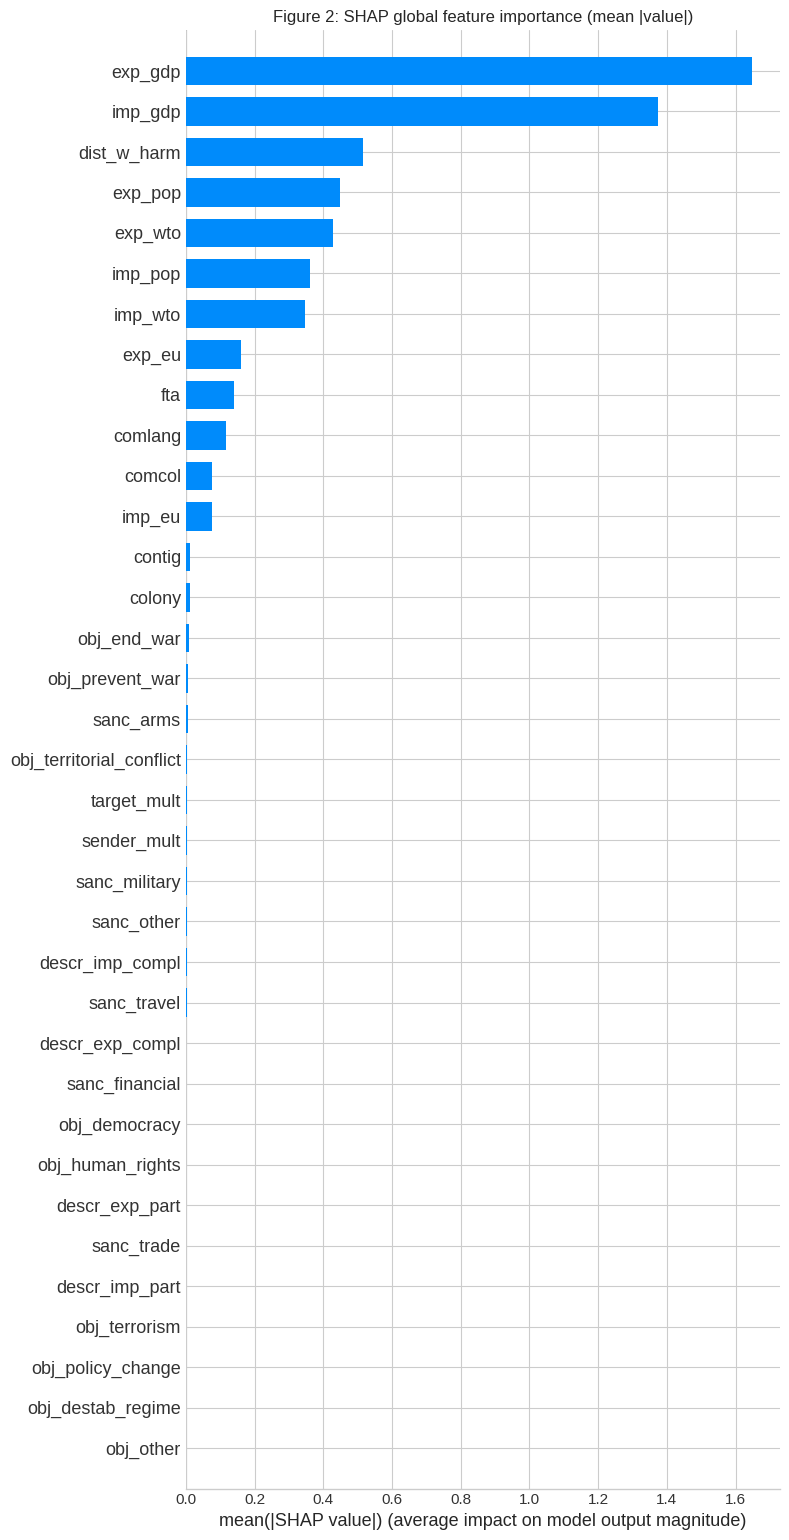

In [11]:
# Figure 2 — global feature importance
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols,
                  plot_type="bar", show=False, max_display=35)
plt.title("Figure 2: SHAP global feature importance (mean |value|)", fontsize=12)
plt.tight_layout()
fig_path = import_path.replace("Cleaned/", "Figures/")
import os; os.makedirs(fig_path, exist_ok=True)
plt.savefig(fig_path + "fig2_shap_bar.pdf", bbox_inches="tight")
plt.show()

better picture

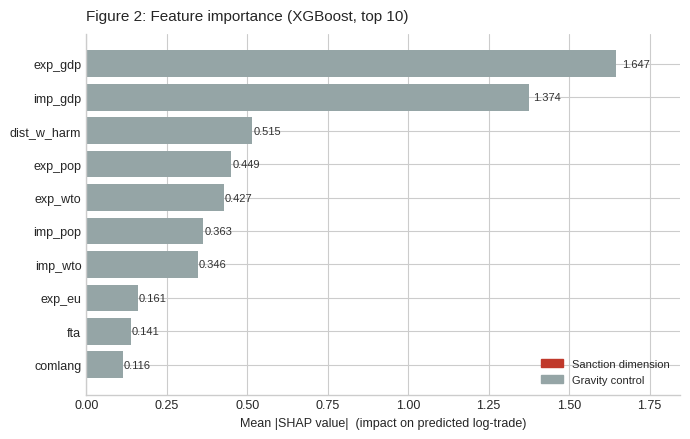

In [12]:
# Figure 2 — top-10 SHAP importance, article-styled
import os

# mean |SHAP| per feature, ranked
mean_abs = np.abs(shap_values).mean(axis=0)
order = np.argsort(mean_abs)[::-1][:10]          # top 10
vals  = mean_abs[order][::-1]                     # reverse for horizontal bar (top at top)
names = [feature_cols[i] for i in order][::-1]

# colour sanction features vs gravity controls
colors = ["#c0392b" if n in sanc_feats else "#95a5a6" for n in names]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.barh(names, vals, color=colors, edgecolor="none")

# value labels at bar ends
for bar, v in zip(bars, vals):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f"{v:.3f}", va="center", ha="left", fontsize=8, color="#333333")

ax.set_xlabel("Mean |SHAP value|  (impact on predicted log-trade)", fontsize=9)
ax.set_title("Figure 2: Feature importance (XGBoost, top 10)", fontsize=11, loc="left", pad=10)
ax.tick_params(labelsize=9)
ax.margins(x=0.12)                                # room for labels
for s in ["top", "right"]:                        # despine
    ax.spines[s].set_visible(False)

# legend explaining the colour split
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#c0392b", label="Sanction dimension"),
                   Patch(color="#95a5a6", label="Gravity control")],
          fontsize=8, frameon=False, loc="lower right")

plt.tight_layout()
fig_path = import_path.replace("Cleaned/", "Figures/")
os.makedirs(fig_path, exist_ok=True)
plt.savefig(fig_path + "fig2_shap_top10.pdf", bbox_inches="tight")
plt.show()

Gravity controls obviously dominate sanctions dimensions. Let's see the situatin between only sanctions dimensions.

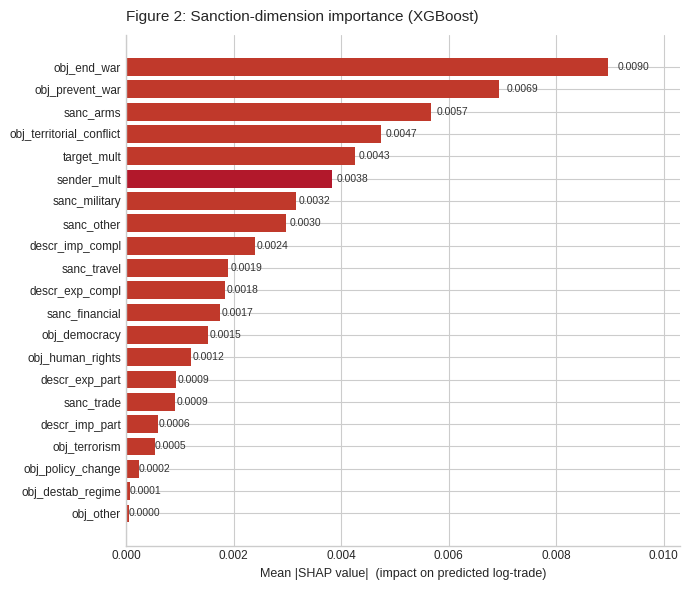

In [13]:
# SHAP importance restricted to sanction dimensions
mean_abs = np.abs(shap_values).mean(axis=0)
sanc_idx = [feature_cols.index(f) for f in sanc_feats]
sanc_imp = [(feature_cols[i], mean_abs[i]) for i in sanc_idx]
sanc_imp.sort(key=lambda x: x[1], reverse=True)

names = [n for n, _ in sanc_imp][::-1]
vals  = [v for _, v in sanc_imp][::-1]
colors = ["#b2182b" if n == "sender_mult" else "#c0392b" for n in names]  # highlight the LASSO pick

fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.barh(names, vals, color=colors, edgecolor="none")
for bar, v in zip(bars, vals):
    ax.text(bar.get_width()*1.02, bar.get_y()+bar.get_height()/2,
            f"{v:.4f}", va="center", ha="left", fontsize=7.5, color="#333")

ax.set_xlabel("Mean |SHAP value|  (impact on predicted log-trade)", fontsize=9)
ax.set_title("Figure 2: Sanction-dimension importance (XGBoost)", fontsize=11, loc="left", pad=10)
ax.tick_params(labelsize=8.5)
ax.margins(x=0.15)
for s in ["top","right"]: ax.spines[s].set_visible(False)

plt.tight_layout()
plt.savefig(fig_path + "fig2_shap_sanctions.pdf", bbox_inches="tight")
plt.show()

Observations:

1) Among sanction dimensions, the model finds objective-type flags (war-related) most predictive of trade patterns.


2) But importance ≠ causal effect, and once you control for pair-level confounders (LASSO), multilateral coordination is what robustly moves trade.


3) The divergence itself argues for the FE-based estimate as the more credible causal claim.

#### Beeswarm — sanctions only

*SHAP = the numbers.*


*Beeswarm = a visualization of those numbers across many observations.*

A SHAP beeswarm plot summarizes how each sanction variable affects model predictions across all observations.

For observation $i$ and sanction variable $k$, the SHAP value $\phi_{ik}$ measures that variable's contribution to the prediction:

$$\hat{y}_i = \phi_0 + \phi_{i1} + \phi_{i2} + \cdots + \phi_{ip}$$

Each dot represents one observation:

* $\phi_{ik} > 0$: the sanction variable pushes predicted trade **up**
* $\phi_{ik} < 0$: it pushes predicted trade **down**
* larger $|\phi_{ik}|$: stronger influence on that prediction

Variables are usually ranked by their mean absolute SHAP value:

$$I_k = \frac{1}{n}\sum_{i=1}^{n}|\phi_{ik}|$$

Thus, variables at the top of the beeswarm have the largest average influence on XGBoost predictions. The color of each dot represents the actual value of the sanction variable.

SHAP measures **predictive contribution, not causal effect**.


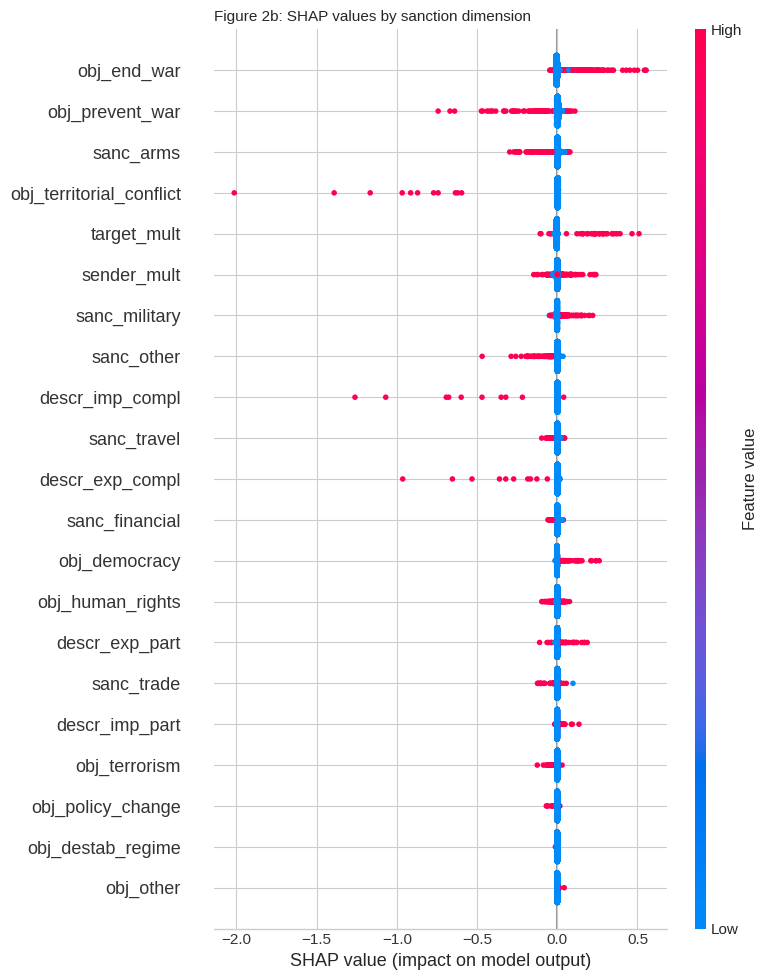

In [14]:
# Beeswarm: direction + magnitude, sanction dimensions only
sanc_idx = [feature_cols.index(f) for f in sanc_feats]

shap.summary_plot(
    shap_values[:, sanc_idx], X_shap[:, sanc_idx],
    feature_names=sanc_feats, plot_type="dot",
    max_display=len(sanc_feats), show=False
)
plt.title("Figure 2b: SHAP values by sanction dimension", fontsize=11, loc="left")
plt.tight_layout()
plt.savefig(fig_path + "fig2b_shap_beeswarm.pdf", bbox_inches="tight")
plt.show()

Note: Observations with positive SHAP values are associated with higher predicted trade in the model — but with no fixed effects this reflects correlation (likely confounding by which dyads receive such sanctions), not a causal increase. Unlike feature importance (which takes the mean of absolute values of SHAPs), SHAP of a particular observation can be either positive or negative.